# Customer Churn Analysis

Comprehensive analysis to predict customer churn using machine learning models.

Shape: (7043, 21)

First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV Str

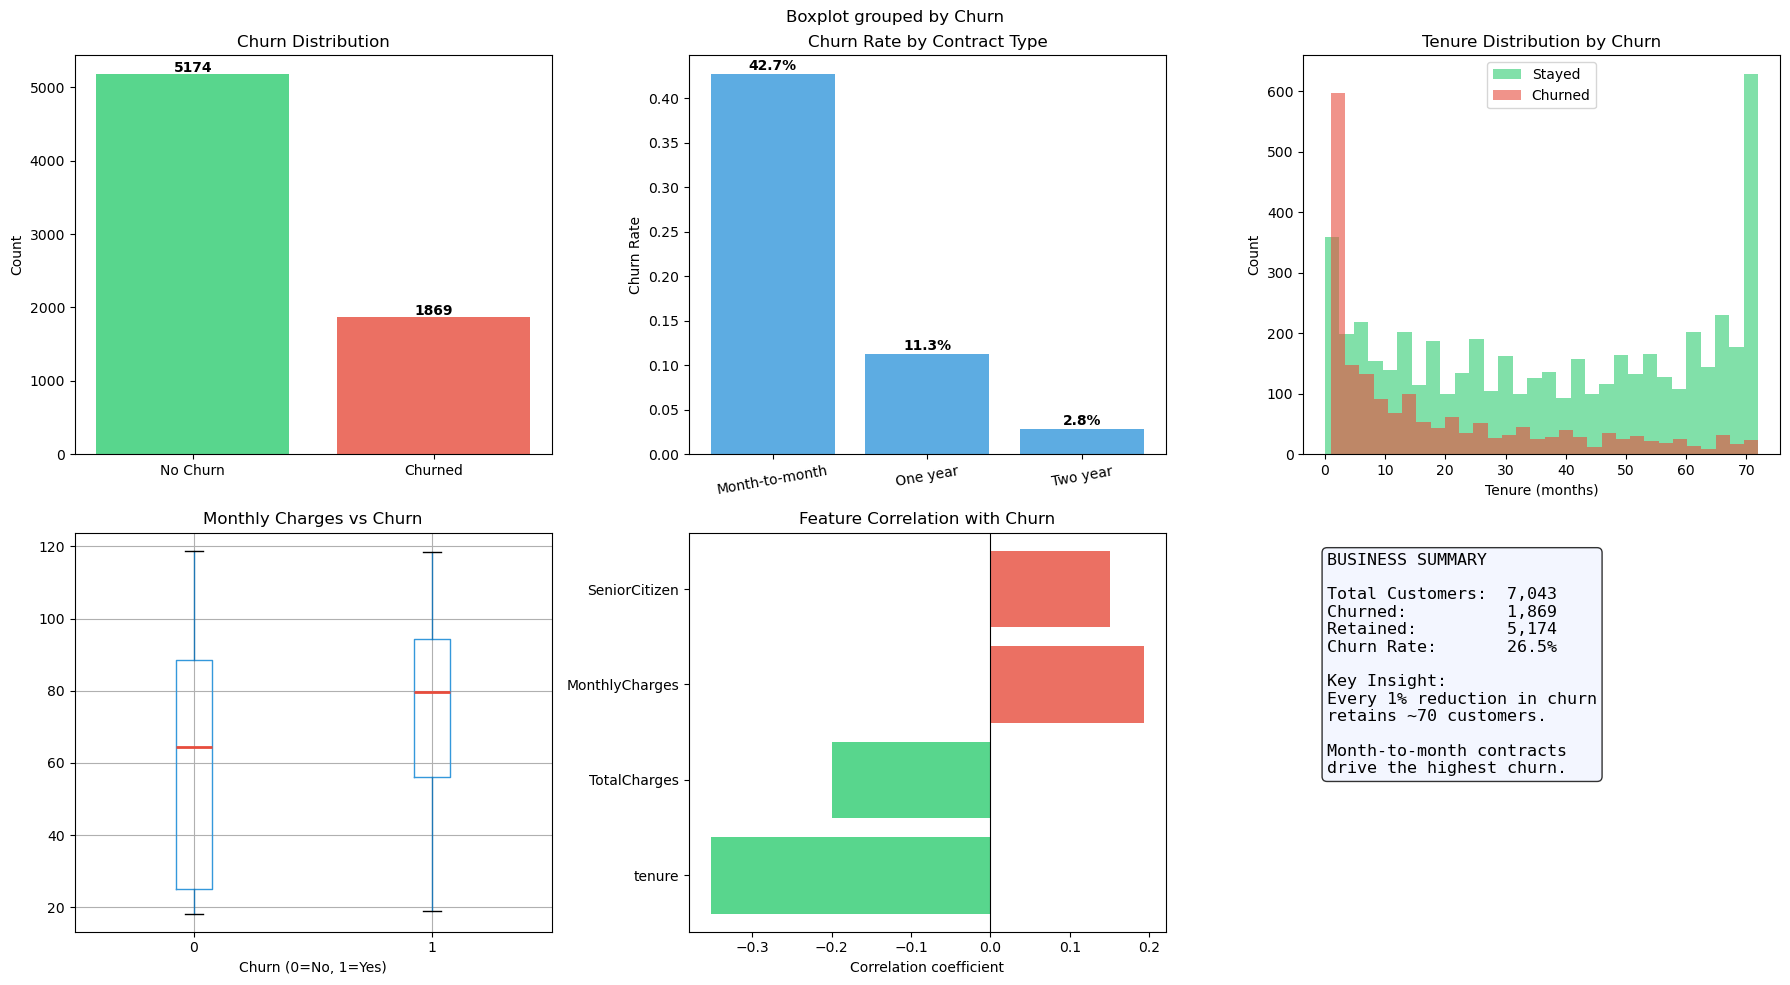


Encoding 15 categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Train size: 5,634  |  Test size: 1,409

 MODEL RESULTS
Logistic Regression — Accuracy: 79.91%  |  AUC: 0.8402
Random Forest       — Accuracy: 79.06%  |  AUC: 0.822
Best model: Logistic Regression


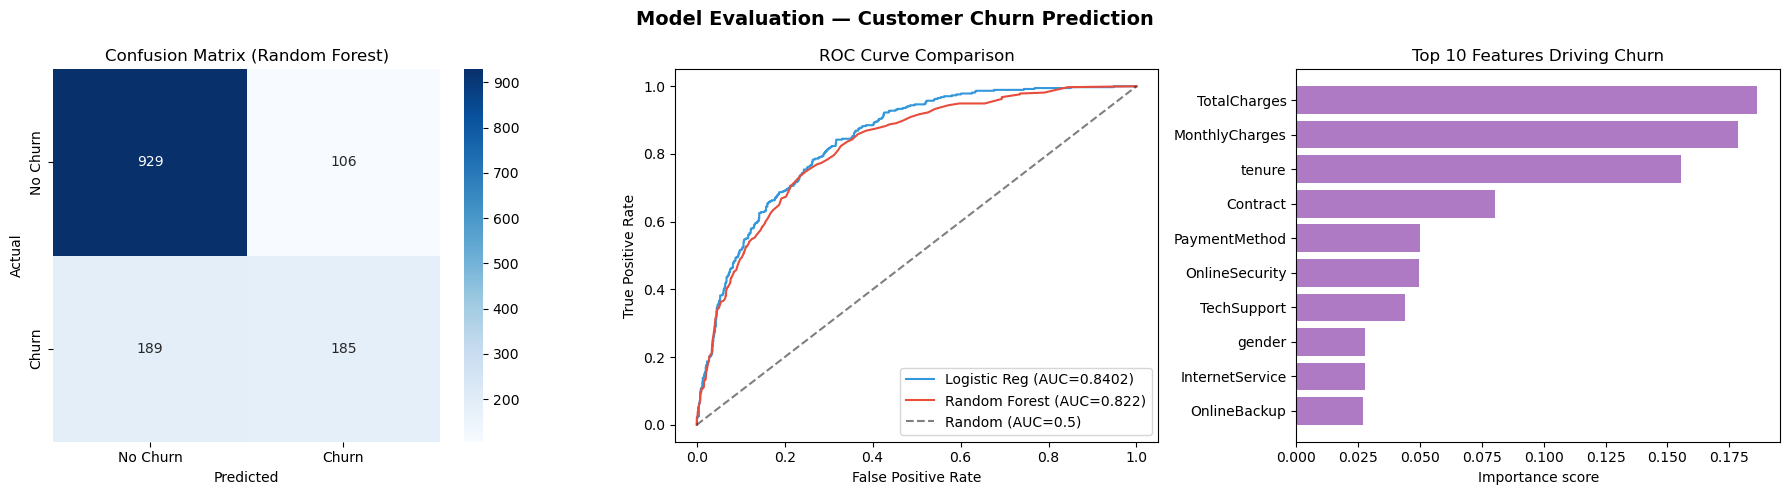


------------------------------------------------------------
BUSINESS RECOMMENDATIONS
------------------------------------------------------------

1. OVERALL CHURN RATE: 26.5%
   → Industry average ~20%. ABOVE average — urgent action needed!

2. MODEL PERFORMANCE:
   → Random Forest Accuracy: 79.06%
   → AUC Score: 0.822 (closer to 1.0 = better)

3. TOP 3 CHURN DRIVERS:
   → TotalCharges: most predictive feature
   → MonthlyCharges: second most predictive
   → tenure: third most predictive

4. RECOMMENDED ACTIONS:
   → Target month-to-month customers with annual plan incentives
   → Flag customers with tenure < 12 months for proactive outreach
   → Offer loyalty discounts to high monthly charge customers

5. FINANCIAL IMPACT:
   → Reducing churn by 5% retains ~352 customers
   → At $50 avg monthly revenue → saves $17,607/month



In [7]:

# PROJECT : CUSTOMER CHURN ANALYSIS
# Tools: Python (pandas, scikit-learn, matplotlib, seaborn)
# Dataset: Telco Customer Churn


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, roc_curve, accuracy_score
)
import warnings
warnings.filterwarnings('ignore')


# STEP 2: LOAD DATA
df = pd.read_csv('/Users/enika/Desktop/Customer churn/Telco customer churn data.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn names:", df.columns.tolist())


# STEP 3: EXPLORE THE DATA 
print("\n--- DATA OVERVIEW ---")
print(df.info())
print("\nMissing values:\n", df.isnull().sum())
print("\nChurn unique values:", df['Churn'].unique())
print("\nChurn value counts:\n", df['Churn'].value_counts())


#  STEP 4: CLEAN THE DATA
# Remove custID
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)


df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.fillna(df.median(numeric_only=True), inplace=True)
# Convert Churn: 'Yes' -> 1, 'No' -> 0
df['Churn'] = df['Churn'].str.strip().map({'Yes': 1, 'No': 0})

# Calculate churn rate AFTER conversion using string keys mapped to 0/1
total = len(df)
churned_count = int(df['Churn'].sum())
not_churned = total - churned_count
churn_rate = round(churned_count / total * 100, 1)

print(f"\nTotal customers: {total:,}")
print(f"Churned: {churned_count:,}")
print(f"Retained: {not_churned:,}")
print(f"Churn rate: {churn_rate}%")


# STEP 5: EXPLORATORY DATA ANALYSIS (EDA) 
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Customer Churn — Exploratory Analysis', fontsize=16, fontweight='bold')

# Plot 1: Churn distribution
axes[0, 0].bar(['No Churn', 'Churned'], [not_churned, churned_count],
                color=['#2ecc71', '#e74c3c'], alpha=0.8)
axes[0, 0].set_title('Churn Distribution')
axes[0, 0].set_ylabel('Count')
for i, v in enumerate([not_churned, churned_count]):
    axes[0, 0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Plot 2: Churn rate by Contract type
contract_churn = df.groupby('Contract')['Churn'].mean().sort_values(ascending=False)
axes[0, 1].bar(range(len(contract_churn)), contract_churn.values, color='#3498db', alpha=0.8)
axes[0, 1].set_xticks(range(len(contract_churn)))
axes[0, 1].set_xticklabels(contract_churn.index, rotation=10)
axes[0, 1].set_title('Churn Rate by Contract Type')
axes[0, 1].set_ylabel('Churn Rate')
for i, v in enumerate(contract_churn.values):
    axes[0, 1].text(i, v + 0.005, f'{v:.1%}', ha='center', fontweight='bold')

# Plot 3: Tenure distribution by Churn
axes[0, 2].hist(df[df['Churn'] == 0]['tenure'], bins=30, alpha=0.6, label='Stayed', color='#2ecc71')
axes[0, 2].hist(df[df['Churn'] == 1]['tenure'], bins=30, alpha=0.6, label='Churned', color='#e74c3c')
axes[0, 2].set_title('Tenure Distribution by Churn')
axes[0, 2].set_xlabel('Tenure (months)')
axes[0, 2].set_ylabel('Count')
axes[0, 2].legend()

# Plot 4: Monthly Charges by Churn
df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[1, 0],
           boxprops=dict(color='#3498db'),
           medianprops=dict(color='#e74c3c', linewidth=2))
axes[1, 0].set_title('Monthly Charges vs Churn')
axes[1, 0].set_xlabel('Churn (0=No, 1=Yes)')
plt.sca(axes[1, 0])
plt.title('Monthly Charges vs Churn')

# Plot 5: Top feature correlations with Churn
numeric_df = df.select_dtypes(include=[np.number])
churn_corr = numeric_df.corr()['Churn'].drop('Churn').sort_values(key=abs, ascending=False).head(8)
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in churn_corr.values]
axes[1, 1].barh(range(len(churn_corr)), churn_corr.values, color=colors, alpha=0.8)
axes[1, 1].set_yticks(range(len(churn_corr)))
axes[1, 1].set_yticklabels(churn_corr.index)
axes[1, 1].set_title('Feature Correlation with Churn')
axes[1, 1].set_xlabel('Correlation coefficient')
axes[1, 1].axvline(0, color='black', linewidth=0.8)

# Plot 6: Business summary
axes[1, 2].axis('off')
summary_text = (
    f"BUSINESS SUMMARY\n\n"
    f"Total Customers:  {total:,}\n"
    f"Churned:          {churned_count:,}\n"
    f"Retained:         {not_churned:,}\n"
    f"Churn Rate:       {churn_rate}%\n\n"
    f"Key Insight:\n"
    f"Every 1% reduction in churn\n"
    f"retains ~{int(total * 0.01):,} customers.\n\n"
    f"Month-to-month contracts\n"
    f"drive the highest churn."
)
axes[1, 2].text(0.05, 0.95, summary_text, transform=axes[1, 2].transAxes,
                fontsize=12, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='#f0f4ff', alpha=0.8))

plt.tight_layout()
plt.savefig('churn_eda.png', dpi=150, bbox_inches='tight')
plt.show()



# STEP 6: PREPARE DATA FOR MODELING 
# Encode all categorical (object) columns
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nEncoding {len(cat_cols)} categorical columns: {cat_cols}")

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# Features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {len(X_train):,}  |  Test size: {len(X_test):,}")


# STEP 7: TRAIN MODELS 
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred  = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]
lr_acc   = round(accuracy_score(y_test, lr_pred) * 100, 2)
lr_auc   = round(roc_auc_score(y_test, lr_proba), 4)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred  = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]
rf_acc   = round(accuracy_score(y_test, rf_pred) * 100, 2)
rf_auc   = round(roc_auc_score(y_test, rf_proba), 4)

print("\n MODEL RESULTS")
print(f"Logistic Regression — Accuracy: {lr_acc}%  |  AUC: {lr_auc}")
print(f"Random Forest       — Accuracy: {rf_acc}%  |  AUC: {rf_auc}")
print(f"Best model: {'Random Forest' if rf_auc > lr_auc else 'Logistic Regression'}")


# ── STEP 8: VISUALISE MODEL RESULTS ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Evaluation — Customer Churn Prediction', fontsize=14, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
axes[0].set_title('Confusion Matrix (Random Forest)')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
axes[1].plot(fpr_lr, tpr_lr, label=f'Logistic Reg (AUC={lr_auc})', color='#3498db')
axes[1].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={rf_auc})', color='#e74c3c')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC=0.5)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve Comparison')
axes[1].legend()

# Feature Importance
feature_names = df.drop('Churn', axis=1).columns
importances = pd.Series(rf_model.feature_importances_, index=feature_names)
top10 = importances.sort_values(ascending=True).tail(10)
axes[2].barh(range(len(top10)), top10.values, color='#9b59b6', alpha=0.8)
axes[2].set_yticks(range(len(top10)))
axes[2].set_yticklabels(top10.index)
axes[2].set_title('Top 10 Features Driving Churn')
axes[2].set_xlabel('Importance score')

plt.tight_layout()
plt.savefig('churn_model_results.png', dpi=150, bbox_inches='tight')
plt.show()



# STEP 9: BUSINESS RECOMMENDATIONS
print("\n" + "-"*60)
print("BUSINESS RECOMMENDATIONS")
print("-"*60)
top3 = importances.sort_values(ascending=False).index[:3].tolist()
print(f"""
1. OVERALL CHURN RATE: {churn_rate}%
   → Industry average ~20%. {'ABOVE average — urgent action needed!' if churn_rate > 20 else 'Within normal range.'}

2. MODEL PERFORMANCE:
   → Random Forest Accuracy: {rf_acc}%
   → AUC Score: {rf_auc} (closer to 1.0 = better)

3. TOP 3 CHURN DRIVERS:
   → {top3[0]}: most predictive feature
   → {top3[1]}: second most predictive
   → {top3[2]}: third most predictive

4. RECOMMENDED ACTIONS:
   → Target month-to-month customers with annual plan incentives
   → Flag customers with tenure < 12 months for proactive outreach
   → Offer loyalty discounts to high monthly charge customers

5. FINANCIAL IMPACT:
   → Reducing churn by 5% retains ~{int(total * 0.05):,} customers
   → At $50 avg monthly revenue → saves ${int(total * 0.05 * 50):,}/month
""")

